# **Customer Segmentation**

In [88]:
# Imported Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [89]:
# Read Dataset
df=pd.read_excel("marketing_campaign.xlsx", sheet_name="marketing_campaign")

In [90]:
# View Dataset
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


# **Statistical Analysis**

In [91]:
# Check no. of Rows and Columns
df.shape

(2240, 29)

In [92]:
# Quick summary of a DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [93]:
# Statistical summary of all numeric columns
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


# **Data Cleaning and EDA**

In [94]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

In [95]:
# Check Missing Values
# Only income column is showing 24 Missing values
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [96]:
# Check column datatypes
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64


In [97]:
# Check for is any id repeated or not
# No id is Repeated as it showing unique values = no. of rows
df['ID'].value_counts()

,count
ID,
1448,1
10659,1
7366,1
6261,1
9246,1
...,...
5324,1
6182,1
4141,1


In [98]:
# Drop ID column as it is not important for prediction
df.drop("ID",axis=1, inplace=True)

In [99]:
# Check the unique values of Education column with its count
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [100]:
# Check the unique values of Marital_Status column with its count
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [101]:
# Find median of Income column for imputing the missing values
df["Income"].median()

51381.5

In [102]:
# Fill null values of Income column with its median
df["Income"].fillna(df["Income"].median(), inplace=True)

In [103]:
# Combined/Replaced similar marital_Status categories for better analysis and modeling
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 'Partner',
    'Together': 'Partner',
    'Single': 'Alone',
    'Alone': 'Alone',
    'Divorced': 'Previously_Married',
    'Widow': 'Previously_Married'
})

In [104]:
# Dropped Absurd and YOLO categories
df=df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

In [105]:
# Check new Value count of Marital_Status Column with replaced Categories
df["Marital_Status"].value_counts()

,count
Marital_Status,
Partner,1444
Alone,483
Previously_Married,309


In [106]:
# Check Value count of Z_CostContact column
# Showing zero Variance
df['Z_CostContact'].value_counts()

,count
Z_CostContact,
3,2236


In [107]:
# Check Value count of Z_Revenue column
# # Showing zero Variance
df['Z_Revenue'].value_counts()

,count
Z_Revenue,
11,2236


In [108]:
# DRopped 'Z_Revenue', 'Z_CostContact' column as it is showing zero variance
df.drop(['Z_Revenue', 'Z_CostContact'], axis=1, inplace=True)

In [109]:
df.shape

(2236, 26)

# **Visualization**

**1. Histogram**

<Figure size 1400x1000 with 0 Axes>

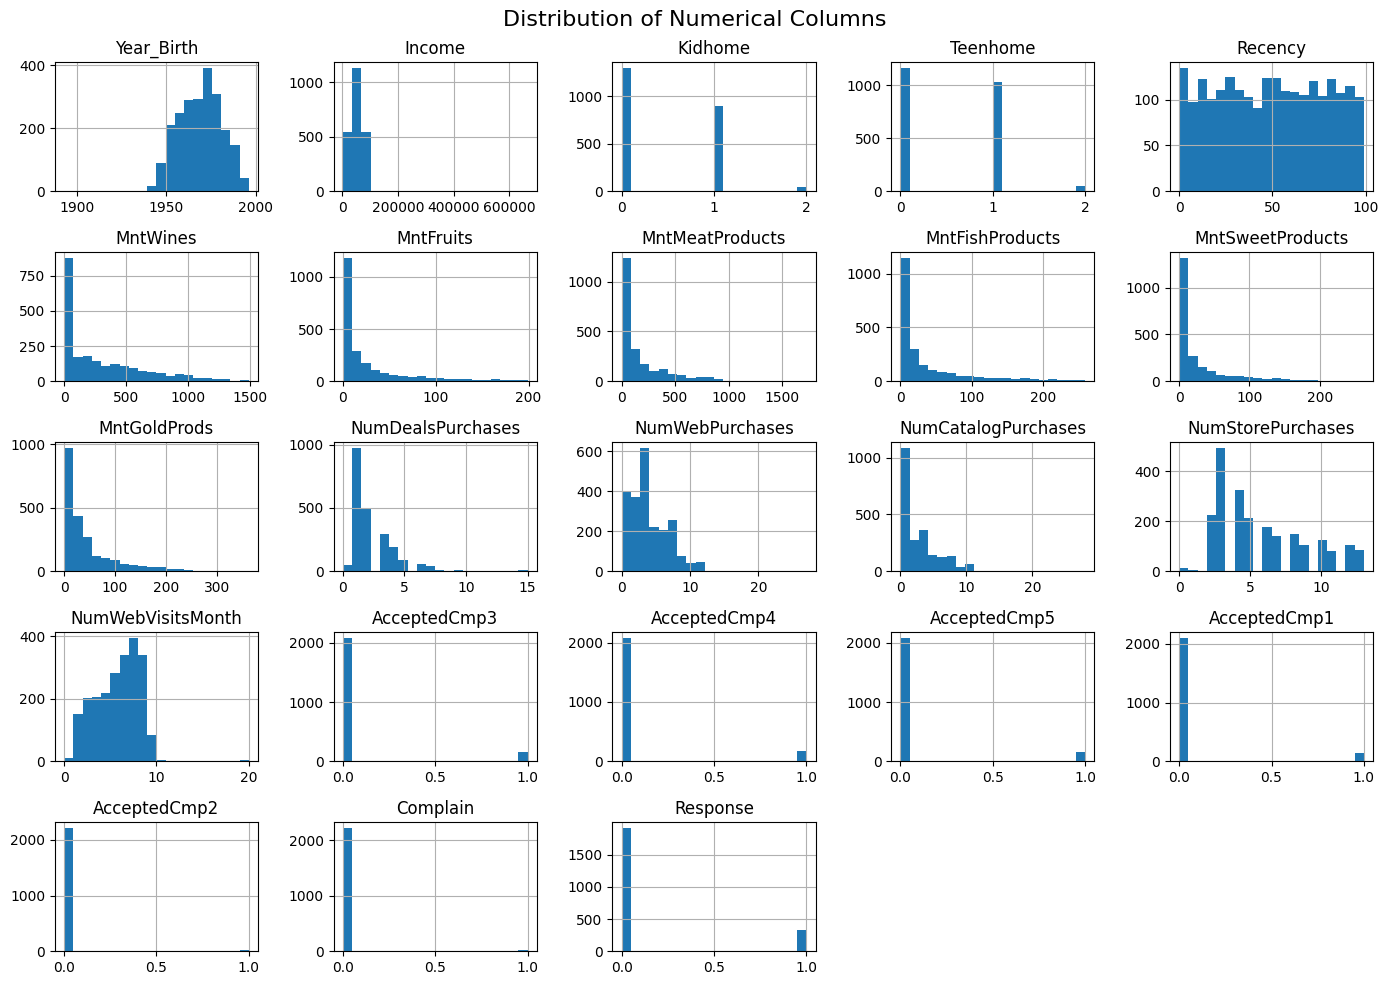

In [110]:
# Plot histograms for numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(14,10))
df[num_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.tight_layout()
plt.show()

**2. Count Plot**

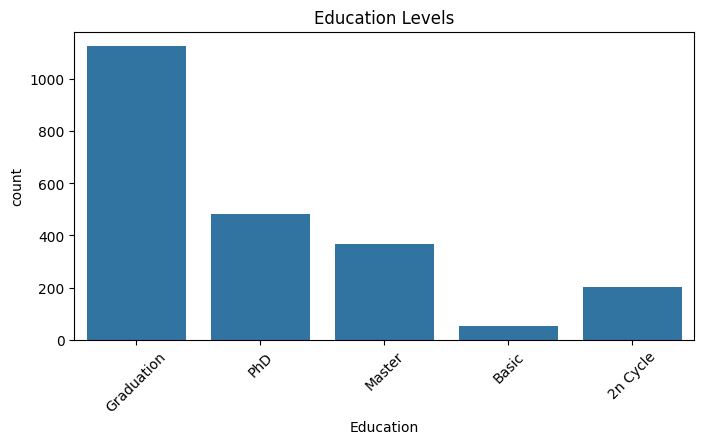

In [111]:
# Categorical Data Visualization

# counts for Education
plt.figure(figsize=(8,4))
sns.countplot(x='Education', data=df)
plt.title("Education Levels")
plt.xticks(rotation=45)
plt.show()

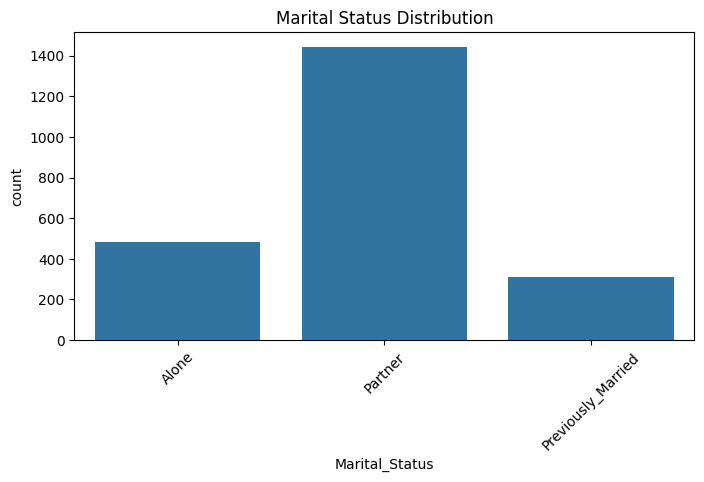

In [112]:
#counts for Marital Status
plt.figure(figsize=(8,4))
sns.countplot(x='Marital_Status', data=df)
plt.title("Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()

**3. Heatmap**

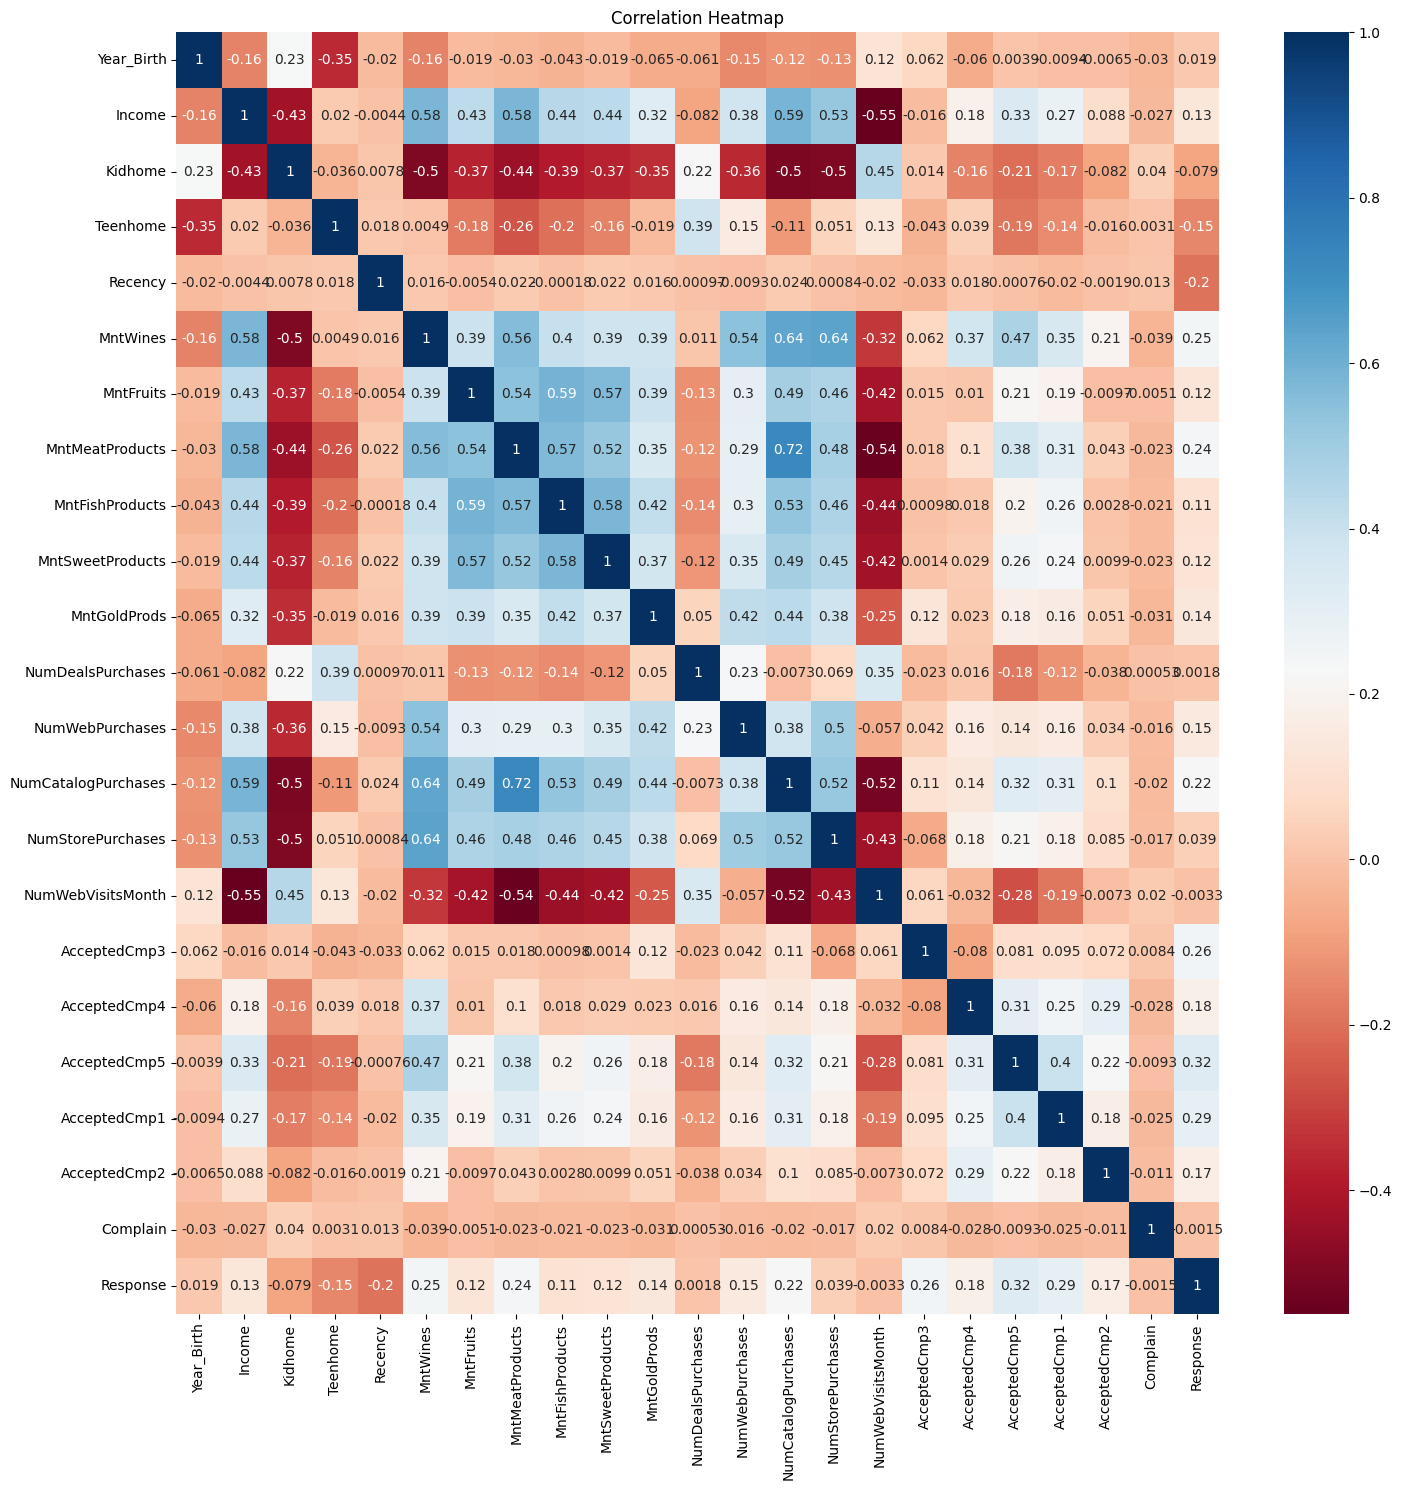

In [113]:
# Correlation Matrix
# Correlation heatmap for numeric columns
numeric_data = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(15,15))
sns.heatmap(numeric_data.corr(), cmap='RdBu', annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**4. Pairplot**

In [114]:
# Pairplot
#sns.pairplot(data=df)

**5. Boxplot**

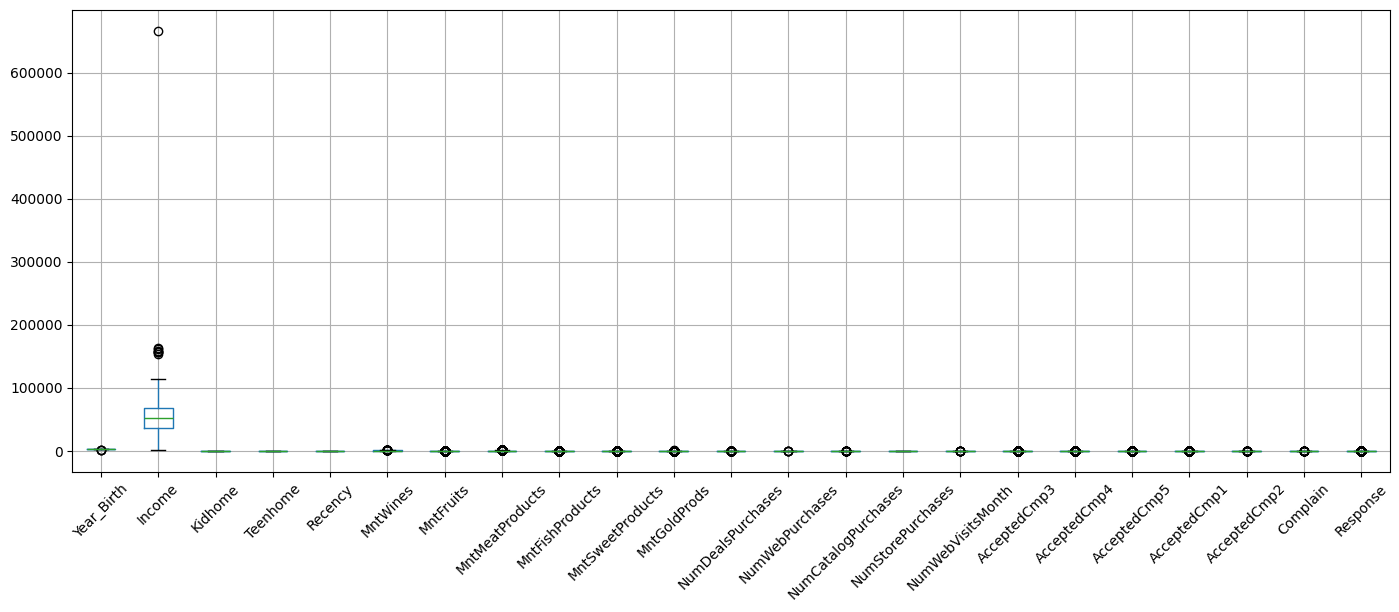

In [115]:
# Boxplot for outlier Detection
plt.figure(figsize=(17,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [116]:
# Handling outliers Using IQR Method
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Cap outliers
df['Income'] = df['Income'].apply(lambda x: upper if x > upper else (lower if x < lower else x))
print(" Min >= lower bound:", df['Income'].min() >= lower)
print(" Max <= upper bound:", df['Income'].max() <= upper)


 Min >= lower bound: True
 Max <= upper bound: True


# **Feature Engineering**

In [117]:
# Creating a new feature that counts the total number of campaigns accepted by each customer
df["Total_Accepted_Campaigns"] = df[
    ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"]
].sum(axis=1)

In [118]:
# Dropped all accepted_campaigns columns as we summed up all this columns into 1 column
df.drop(["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"], axis=1, inplace=True)

In [119]:
# Created a new column 'Age' from 'Year_Birth'
# Converts birth year → customer age.
df['Age'] = 2026 - df['Year_Birth']

In [120]:
# Check value count of age...... for three entries it is showing age>100 .....so it is an outlier
df["Age"].value_counts()

,count
Age,
50,89
55,87
51,83
54,79
48,77
56,77
61,74
53,72
57,71


In [121]:
# Deleted the entries which having age>=100
df = df[df['Age'] <= 100]

In [122]:
# Max value of age is now 86 so outlier entries are deleted successfully
df['Age'].max()

86

In [123]:
# Created 'TotalChildren' = Kidhome + Teenhome
# Total number of children in the household.
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

In [124]:
# Created 'TotalSpend' = total money spent across all product categories
# Total money spent across all product categories.
df['TotalSpend'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

In [125]:
# Create 'FamilySize'

# Created a binary column 'IsPartner' where 1 indicates the customer has a partner and 0 otherwise
df['IsPartner'] = df['Marital_Status'].apply(lambda x: 1 if x == 'Partner' else 0)

# Calculate 'FamilySize' as total children + the customer (1) + partner if present
df['FamilySize'] = df['TotalChildren'] + 1 + df['IsPartner']

In [126]:
# Created a new feature 'TotalPurchases' by summing purchases made through web, catalog, and store
df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

In [127]:
# created customer tenure feature from 'Dt_Customer' feature
df['Customer_Tenure'] = 2026 - df['Dt_Customer'].dt.year

In [128]:
# Dropped 'Year_Birth','Kidhome','Teenhome','IsPartner','Dt_Customer' columns as it is not longer needed bcoz we created new features from them
df.drop(['Year_Birth','Kidhome','Teenhome','IsPartner','Dt_Customer'], axis=1, inplace=True)

In [129]:
df.drop(['MntWines','MntFruits','MntMeatProducts',
         'MntFishProducts','MntSweetProducts','MntGoldProds'], axis=1, inplace=True)

In [130]:
# Dropped the 'Response' feature from the DataFrame to prevent it from being used in feature-based analysis
df.drop('Response', axis=1, inplace=True)

In [131]:
print("Feature Engineering done successfully!")

Feature Engineering done successfully!


**Visualization after Feature Engineering**

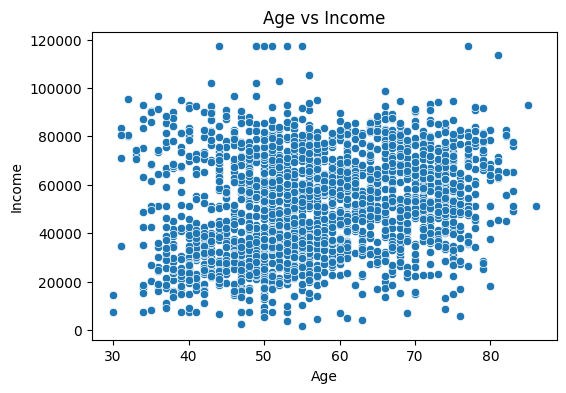

In [132]:
# Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Income', data=df)
plt.title("Age vs Income")
plt.show()

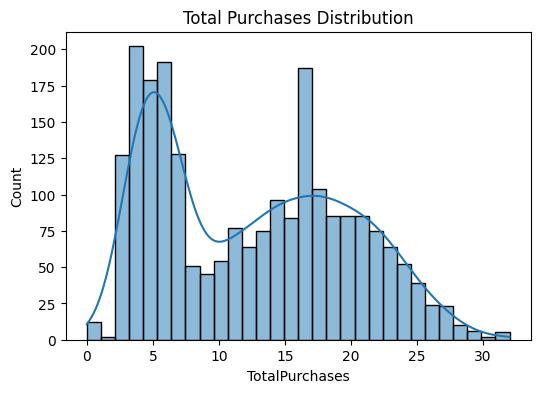

In [133]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['TotalPurchases'], bins=30, kde=True)
plt.title("Total Purchases Distribution")
plt.show()

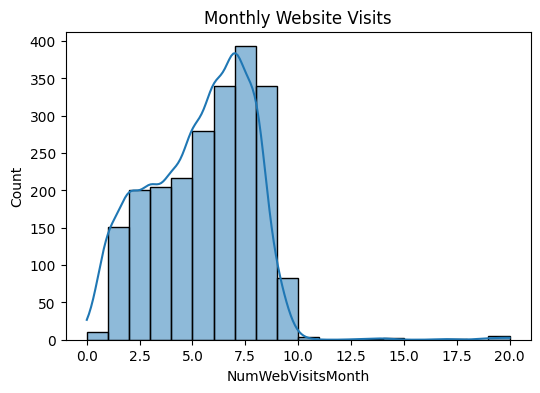

In [134]:
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['NumWebVisitsMonth'], bins=20, kde=True)
plt.title("Monthly Website Visits")
plt.show()

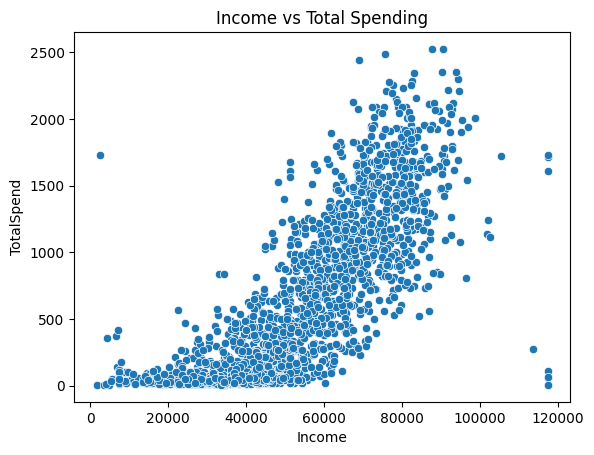

In [135]:
# Scatterplot
sns.scatterplot(x='Income', y='TotalSpend', data=df)
plt.title("Income vs Total Spending")
plt.show()

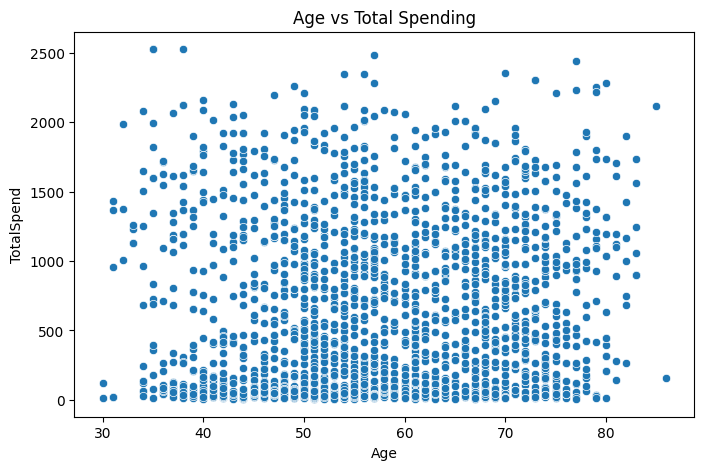

In [136]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Age", y="TotalSpend", data=df)

plt.title("Age vs Total Spending")

plt.show()

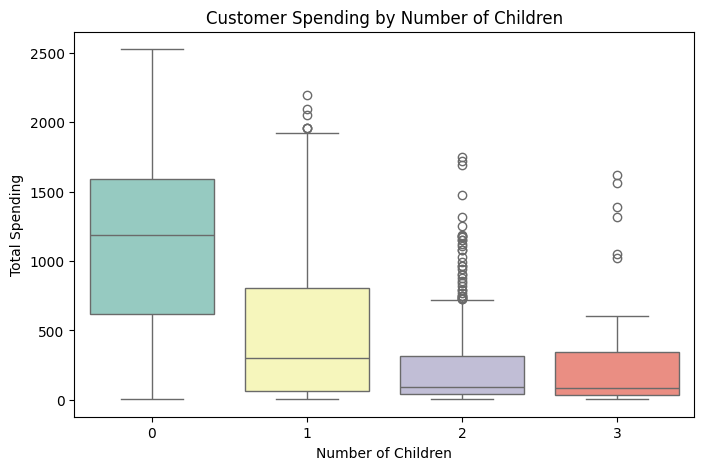

In [137]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="TotalChildren",
    y="TotalSpend",
    data=df,
    palette="Set3"
)

plt.title("Customer Spending by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Total Spending")

plt.show()

In [138]:
df.drop('TotalChildren', axis=1, inplace=True)

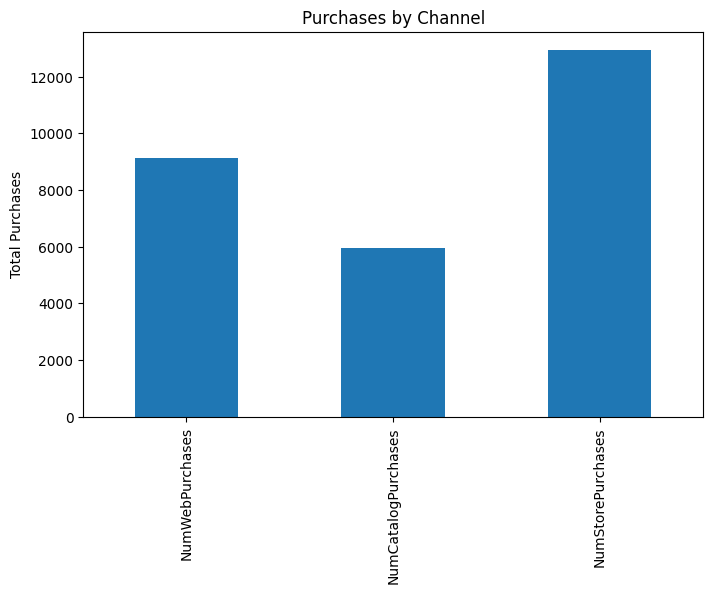

In [139]:
channels = df[
['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
].sum()

plt.figure(figsize=(8,5))

channels.plot(kind="bar")

plt.title("Purchases by Channel")

plt.ylabel("Total Purchases")

plt.show()

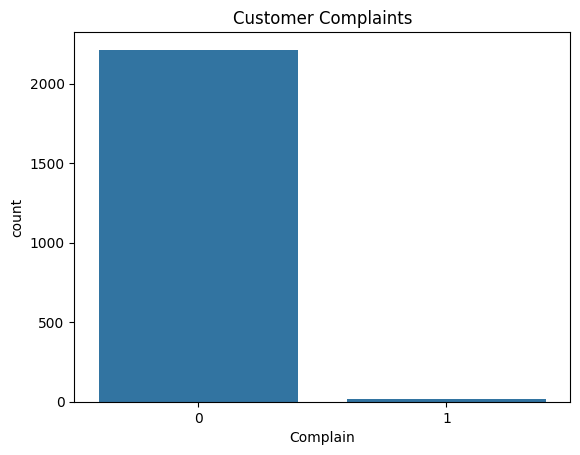

In [140]:
sns.countplot(x="Complain", data=df)
plt.title("Customer Complaints")
plt.show()

# **Data Transformation**

In [141]:
# Convert categorical columns into numerical using One-Hot Encoding
df = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=True)

In [142]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [143]:
# Final DataFrame
df

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Total_Accepted_Campaigns,Age,TotalSpend,FamilySize,TotalPurchases,Customer_Tenure,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Partner,Marital_Status_Previously_Married
0,58138.0,58,3,8,10,4,7,0,0,69,1617,1,22,14,False,True,False,False,False,False
1,46344.0,38,2,1,1,2,5,0,0,72,27,3,4,12,False,True,False,False,False,False
2,71613.0,26,1,8,2,10,4,0,0,61,776,2,20,13,False,True,False,False,True,False
3,26646.0,26,2,2,0,4,6,0,0,42,53,3,6,12,False,True,False,False,True,False
4,58293.0,94,5,5,3,6,5,0,0,45,422,3,14,12,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,1341,3,16,13,False,True,False,False,True,False
2236,64014.0,56,7,8,2,5,7,0,1,80,444,5,15,12,False,False,False,True,True,False
2237,56981.0,91,1,2,3,13,6,0,1,45,1241,1,18,12,False,True,False,False,False,True
2238,69245.0,8,2,6,5,10,3,0,0,70,843,3,21,12,False,False,True,False,True,False


In [144]:
df.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Total_Accepted_Campaigns', 'Age', 'TotalSpend',
       'FamilySize', 'TotalPurchases', 'Customer_Tenure', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Partner', 'Marital_Status_Previously_Married'],
      dtype='object')

# **PCA**

In [145]:
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(df_scaled)

In [146]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [147]:
print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[2.55870034e-01 9.94719948e-02 8.32148625e-02 8.16329625e-02
 6.23466063e-02 6.15111272e-02 5.05870984e-02 4.96943956e-02
 4.50146496e-02 4.24245554e-02 3.97817803e-02 3.08535548e-02
 2.53197111e-02 2.11173695e-02 1.64739908e-02 1.19117248e-02
 1.00039393e-02 6.82647215e-03 5.94317067e-03 9.64353152e-18]


In [148]:
print("Cumulative Variance:")
print(cumulative_variance)

Cumulative Variance:
[0.25587003 0.35534203 0.43855689 0.52018985 0.58253646 0.64404759
 0.69463469 0.74432908 0.78934373 0.83176829 0.87155007 0.90240362
 0.92772333 0.9488407  0.96531469 0.97722642 0.98723036 0.99405683
 1.         1.        ]


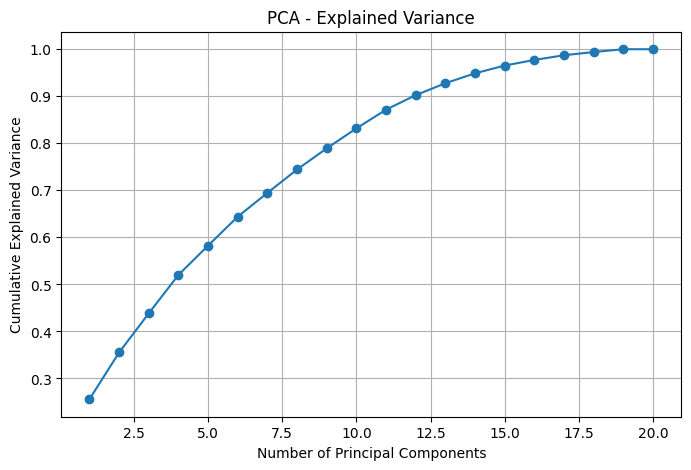

In [149]:
# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.grid(True)
plt.show()

In [150]:
pca = PCA(n_components=9)
pca_data = pca.fit_transform(df_scaled)

# **1. K-Means**

In [151]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)

score = silhouette_score(pca_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.1780763913190961


In [152]:
df_result = df.copy()
df_result['KMeans_Cluster'] = clusters

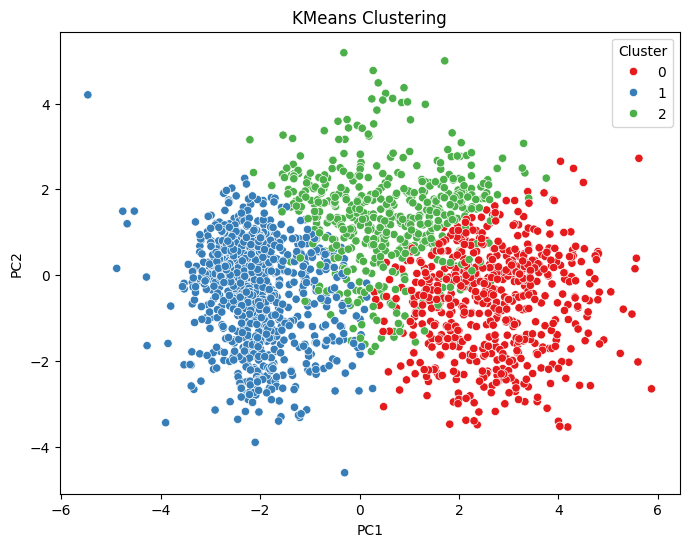

In [153]:
# Visualization
plot_df_kmeans = pd.DataFrame(pca_data[:, :2], columns=['PC1', 'PC2'])
plot_df_kmeans['Cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=plot_df_kmeans, palette='Set1')
plt.title("KMeans Clustering")
plt.show()

# **2. DBSCAN**

In [154]:
# Apply DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

clusters_db = dbscan.fit_predict(pca_data)

In [155]:
# Check Clusters
import numpy as np

print(np.unique(clusters_db))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [156]:
# Count Clusters
print("Number of clusters:", len(set(clusters_db)) - (1 if -1 in clusters_db else 0))

Number of clusters: 16


In [157]:
# Check noisy points
print("Noise points:", list(clusters_db).count(-1))

Noise points: 378


In [158]:
# Silhouette Score

# Remove noise (-1)
mask = clusters_db != -1

if len(set(clusters_db[mask])) > 1:
    score = silhouette_score(pca_data[mask], clusters_db[mask])
    print("Silhouette Score:", score)

Silhouette Score: -0.05682331161240629


In [159]:
# Hyperparameter tuning
for eps in [0.5, 1, 1.5, 2]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(pca_data)
    print("eps =", eps, "clusters =", len(set(labels)))

eps = 0.5 clusters = 7
eps = 1 clusters = 35
eps = 1.5 clusters = 17
eps = 2 clusters = 4


In [160]:
# Retrain model with best parameters and predict the clusters
dbscan = DBSCAN(eps=2, min_samples=5)
labels = dbscan.fit_predict(pca_data)

print("Clusters:", set(labels))
print("Noise:", list(labels).count(-1))

Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
Noise: 70


In [161]:
# Silhouette score

mask = labels != -1
if len(set(labels[mask])) > 1:
    print(silhouette_score(pca_data[mask], labels[mask]))

0.162039146191336


# **3. Hierarchical Clustering**

In [162]:
# Import Library
from scipy.cluster.hierarchy import dendrogram, linkage

In [163]:
# Create linkage matrix
linked = linkage(pca_data, method='ward')

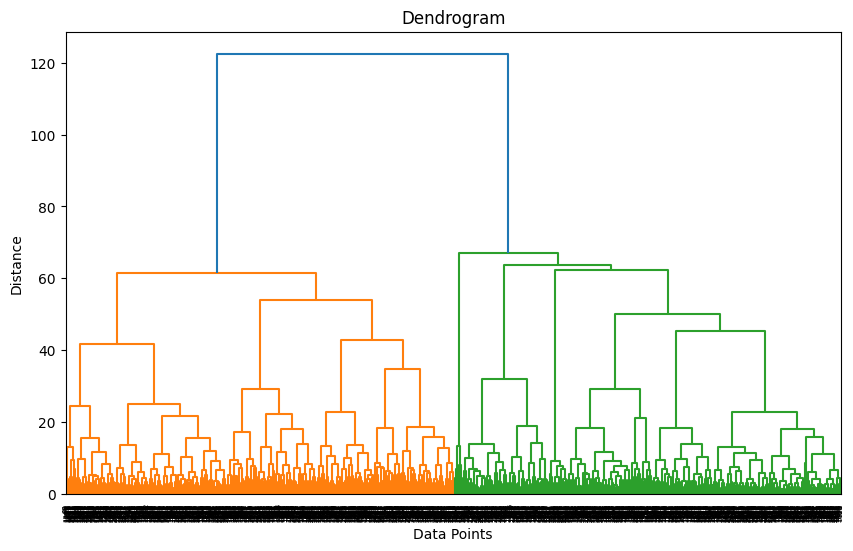

In [164]:
# Plot Densrogram
plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [165]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)

clusters_hc = hc.fit_predict(pca_data)

In [166]:
# Silhouette Score
score = silhouette_score(pca_data, clusters_hc)
print("Silhouette Score:", score)

Silhouette Score: 0.21612005483749433


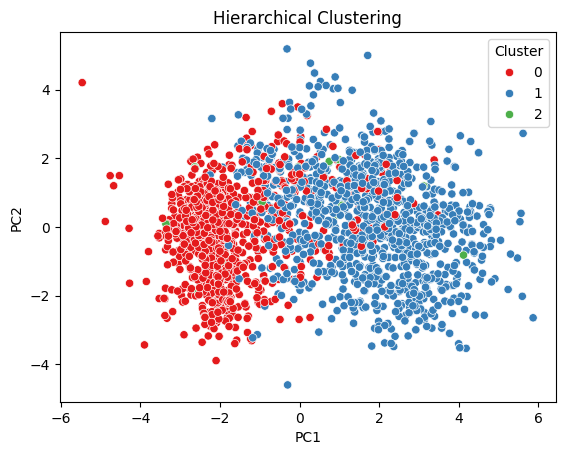

In [167]:
# Cluster Visualization
plot_df = pd.DataFrame(pca_data[:, :2], columns=['PC1','PC2'])
plot_df['Cluster'] = clusters_hc

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=plot_df, palette='Set1')
plt.title("Hierarchical Clustering")
plt.show()

# **Fit all 3 models**

In [168]:
# -----------------------------
# KMeans
# -----------------------------
km = KMeans(n_clusters=3, random_state=42, n_init=20)
km_labels = km.fit_predict(pca_data)
km_sil = silhouette_score(pca_data, km_labels)

# cluster sizes
km_sizes = [int((km_labels == i).sum()) for i in range(3)]

# -----------------------------
# Hierarchical Clustering
# -----------------------------
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(pca_data)
hc_sil = silhouette_score(pca_data, hc_labels)

# cluster sizes
hc_sizes = [int((hc_labels == i).sum()) for i in range(3)]

# -----------------------------
# DBSCAN
# -----------------------------
best_db = DBSCAN(eps=2.5, min_samples=5)
db_labels = best_db.fit_predict(pca_data)

db_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise = list(db_labels).count(-1)

mask = db_labels != -1
if len(set(db_labels[mask])) > 1:
    db_sil = silhouette_score(pca_data[mask], db_labels[mask])
else:
    db_sil = np.nan

# cluster sizes excluding noise
db_sizes = [int((db_labels == i).sum()) for i in sorted(set(db_labels)) if i != -1]

# **Side-by-side cluster visualizations**

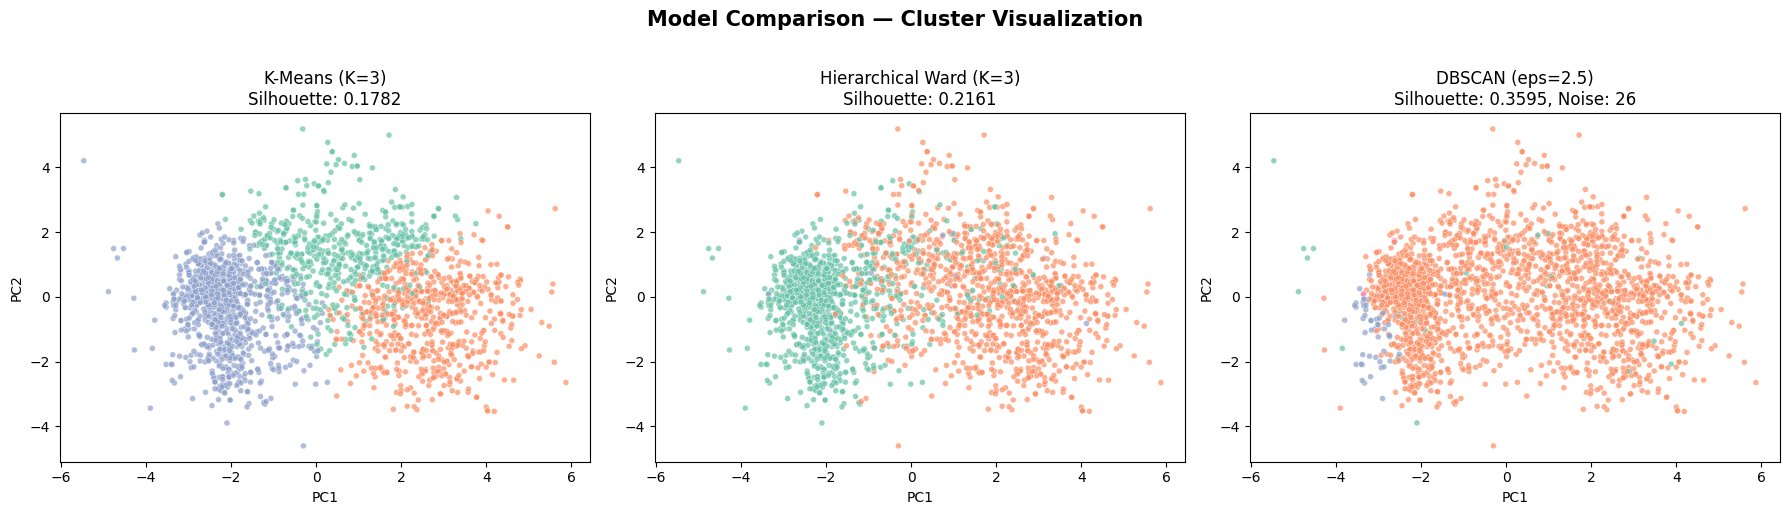

In [169]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
sns.scatterplot(
    x=pca_data[:, 0], y=pca_data[:, 1],
    hue=km_labels, palette='Set2', s=18, alpha=0.7, ax=axes[0], legend=False
)
axes[0].set_title(f'K-Means (K=3)\nSilhouette: {km_sil:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Hierarchical
sns.scatterplot(
    x=pca_data[:, 0], y=pca_data[:, 1],
    hue=hc_labels, palette='Set2', s=18, alpha=0.7, ax=axes[1], legend=False
)
axes[1].set_title(f'Hierarchical Ward (K=3)\nSilhouette: {hc_sil:.4f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# DBSCAN
plot_db = np.where(db_labels == -1, -1, db_labels)
sns.scatterplot(
    x=pca_data[:, 0], y=pca_data[:, 1],
    hue=plot_db, palette='Set2', s=18, alpha=0.7, ax=axes[2], legend=False
)
axes[2].set_title(f'DBSCAN (eps=2.5)\nSilhouette: {db_sil:.4f}, Noise: {db_noise}')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.suptitle('Model Comparison — Cluster Visualization', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Comparison summary table**

In [170]:
print('=' * 90)
print('MODEL COMPARISON SUMMARY')
print('=' * 90)
print(f'{"Model":<30s} {"Clusters":<10s} {"Silhouette":<12s} {"Noise":<8s} {"Cluster Sizes"}')
print('-' * 90)

print(f'{"K-Means (K=3)":<30s} {3:<10d} {km_sil:<12.4f} {"0":<8s} {km_sizes}')
print(f'{"Hierarchical Ward (K=3)":<30s} {3:<10d} {hc_sil:<12.4f} {"0":<8s} {hc_sizes}')
print(f'{"DBSCAN (best)":<30s} {db_n_clusters:<10d} {db_sil:<12.4f} {str(db_noise):<8s} {db_sizes}')

print('=' * 90)

MODEL COMPARISON SUMMARY
Model                          Clusters   Silhouette   Noise    Cluster Sizes
------------------------------------------------------------------------------------------
K-Means (K=3)                  3          0.1782       0        [563, 660, 1010]
Hierarchical Ward (K=3)        3          0.2161       0        [1091, 1122, 20]
DBSCAN (best)                  3          0.3595       26       [2150, 52, 5]


# **Cluster profiles across models**

In [171]:
profile_cols = ['Income', 'TotalSpend', 'TotalPurchases', 'FamilySize',
                'Total_Accepted_Campaigns', 'NumDealsPurchases']

In [172]:
print("\nK-MEANS CLUSTER PROFILES:")
temp_km = df.copy()
temp_km['Cluster'] = km_labels
print(temp_km.groupby('Cluster')[profile_cols].mean().round(1).to_string())

print("\nHIERARCHICAL CLUSTER PROFILES:")
temp_hc = df.copy()
temp_hc['Cluster'] = hc_labels
print(temp_hc.groupby('Cluster')[profile_cols].mean().round(1).to_string())

if db_n_clusters >= 2:
    print(f"\nDBSCAN CLUSTER PROFILES (excluding {db_noise} noise points):")
    temp_db = df.copy()
    temp_db['Cluster'] = db_labels
    temp_db_clean = temp_db[temp_db['Cluster'] != -1]
    print(temp_db_clean.groupby('Cluster')[profile_cols].mean().round(1).to_string())


K-MEANS CLUSTER PROFILES:
          Income  TotalSpend  TotalPurchases  FamilySize  Total_Accepted_Campaigns  NumDealsPurchases
Cluster                                                                                              
0        55735.5       705.7            16.6         3.0                       0.2                4.2
1        74631.2      1303.5            19.5         1.8                       0.7                1.3
2        34774.6        93.2             5.7         2.9                       0.1                1.9

HIERARCHICAL CLUSTER PROFILES:
          Income  TotalSpend  TotalPurchases  FamilySize  Total_Accepted_Campaigns  NumDealsPurchases
Cluster                                                                                              
0        37016.1       156.7             6.8         2.9                       0.1                2.1
1        66363.7      1045.5            18.1         2.3                       0.5                2.5
2        45672.4       

DBSCAN achieved the highest silhouette score, but the score was computed after excluding noise points, so it is not directly comparable to KMeans and Hierarchical clustering evaluated on the full dataset.

**KMeans**
Lower silhouette
But clusters look balanced and interpretable
Good for business use              
**Hierarchical**
Better than KMeans by score
Still reasonably interpretable                      
**DBSCAN**
Highest silhouette
But likely benefits from excluding noise
Cluster sizes may be imbalanced
May be less useful for actionable segmentation

Among the three models, DBSCAN produced the highest silhouette score. However, this score was calculated after excluding noise points, making direct comparison with KMeans and Hierarchical Clustering less straightforward. KMeans and Hierarchical Clustering produced more balanced and interpretable customer segments. Therefore, for business-oriented customer segmentation, KMeans/Hierarchical may still be preferred despite DBSCAN’s higher silhouette score.

**KMeans produced more balanced and well-separated clusters compared to hierarchical clustering, which showed more overlap between clusters.**

In customer segmentation:

We want:
High spenders
Medium customers
Low customers

👉 KMeans:

Creates clear segments

👉 Hierarchical:

More mixed patterns

**KMeans clusters were easier to interpret and align better with business segmentation use cases.**

**KMeans is computationally efficient and scalable, making it more suitable for real-world deployment compared to hierarchical clustering.**

**Although hierarchical clustering achieved a slightly higher silhouette score, the difference was marginal and did not outweigh the advantages of KMeans in terms of interpretability and cluster balance.**

**Among the three models, KMeans, DBSCAN, and Hierarchical Clustering, KMeans was selected as the final model. Although hierarchical clustering achieved a slightly higher silhouette score, the difference was marginal. KMeans produced more balanced and well-separated clusters, which were easier to interpret for customer segmentation. Additionally, KMeans is computationally efficient, scalable, and widely used in industry applications. Therefore, KMeans was chosen as the final model for this project.**

In [173]:
df_check = df.copy()
df_check["Cluster"] = kmeans.labels_

print(df_check.groupby("Cluster")[["Income", "TotalSpend", "TotalPurchases"]].mean())

               Income   TotalSpend  TotalPurchases
Cluster                                           
0        74601.424924  1303.396369       19.526475
1        34774.627723    93.246535        5.702970
2        55736.884564   704.788256       16.603203


In [174]:
segment_map = {
    0: "Premium Customers",
    1: "Low Value Customers",
    2: "Mid Value Customers"
}

In [176]:
# Save model
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("pca", pca),
    ("kmeans", kmeans)
])

joblib.dump(pipeline, "model_pipeline.pkl")

['model_pipeline.pkl']